# Feature Engineering Experiments for IEEE-CIS Fraud Detection

This notebook explores candidate features that may improve fraud detection performance, including time-derived variables, amount transformations, identity coverage indicators, and missingness-based features.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data" / "raw").exists():
    ROOT_DIR = (ROOT_DIR / ".." / "..").resolve()

DATA_DIR = ROOT_DIR / "data" / "raw"
FIGURES_DIR = ROOT_DIR / "reports" / "figures"
SUMMARY_DIR = ROOT_DIR / "reports" / "model_reports"

TRAIN_TRANSACTION_FILE = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_FILE = DATA_DIR / "train_identity.csv"
FEATURE_STRATEGY_SUMMARY_FILE = SUMMARY_DIR / "feature_engineering_candidate_summary.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
transaction_columns = [
    "TransactionID",
    "isFraud",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain",
]

identity_columns = [
    "TransactionID",
    "DeviceType",
    "DeviceInfo",
]

train_transaction = pd.read_csv(TRAIN_TRANSACTION_FILE, usecols=transaction_columns)
train_identity = pd.read_csv(TRAIN_IDENTITY_FILE, usecols=identity_columns)

train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,P_emaildomain,R_emaildomain
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,gmail.com,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,outlook.com,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,yahoo.com,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,gmail.com,NaN


In [3]:
def build_candidate_features(train_transaction: pd.DataFrame, train_identity: pd.DataFrame) -> pd.DataFrame:
    df = train_transaction.copy()
    identity_ids = set(train_identity["TransactionID"])

    df["transaction_hour"] = (df["TransactionDT"] // 3600) % 24
    df["transaction_day"] = df["TransactionDT"] // 86400
    df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])
    df["has_identity"] = df["TransactionID"].isin(identity_ids).astype(int)

    df["P_emaildomain_missing"] = df["P_emaildomain"].isna().astype(int)
    df["R_emaildomain_missing"] = df["R_emaildomain"].isna().astype(int)
    df["email_domain_match"] = np.where(
        df["P_emaildomain"].notna() & df["R_emaildomain"].notna(),
        (df["P_emaildomain"] == df["R_emaildomain"]).astype(int),
        -1,
    )

    card_columns = ["card1", "card2", "card3", "card4", "card5", "card6"]
    df["card_missing_count"] = df[card_columns].isna().sum(axis=1)

    address_columns = ["addr1", "addr2"]
    df["address_missing_count"] = df[address_columns].isna().sum(axis=1)

    return df

feature_df = build_candidate_features(train_transaction, train_identity)
feature_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,R_emaildomain,transaction_hour,transaction_day,TransactionAmt_log,has_identity,P_emaildomain_missing,R_emaildomain_missing,email_domain_match,card_missing_count,address_missing_count
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,0,1,4.241327,0,1,1,-1,1,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,0,1,3.401197,0,0,1,-1,0,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,0,1,4.094345,0,0,1,-1,0,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,0,1,3.931826,0,0,1,-1,0,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,NaN,0,1,3.931826,1,0,1,-1,0,0


In [4]:
candidate_columns = [
    "TransactionAmt",
    "TransactionAmt_log",
    "transaction_hour",
    "transaction_day",
    "ProductCD",
    "has_identity",
    "P_emaildomain_missing",
    "R_emaildomain_missing",
    "email_domain_match",
    "card_missing_count",
    "address_missing_count",
]

summary = []
for column in candidate_columns:
    summary.append({
        "feature_name": column,
        "data_type": str(feature_df[column].dtype),
        "missing_percentage": round(feature_df[column].isna().mean() * 100, 3),
        "unique_values": feature_df[column].nunique(dropna=True),
        "example_values": feature_df[column].dropna().astype(str).head(5).tolist(),
    })

summary_df = pd.DataFrame(summary)
summary_df

,feature_name,data_type,missing_percentage,unique_values,example_values
0,TransactionAmt,float64,0.0,20902,"[68.5, 29.0, 59.0, 50.0, 50.0]"
1,TransactionAmt_log,float64,0.0,20902,"[4.241326752570746, 3.4011973816621555, 4.0943..."
2,transaction_hour,int64,0.0,24,"[0, 0, 0, 0, 0]"
3,transaction_day,int64,0.0,182,"[1, 1, 1, 1, 1]"
4,ProductCD,str,0.0,5,"[W, W, W, W, H]"
5,has_identity,int64,0.0,2,"[0, 0, 0, 0, 1]"
6,P_emaildomain_missing,int64,0.0,2,"[1, 0, 0, 0, 0]"
7,R_emaildomain_missing,int64,0.0,2,"[1, 1, 1, 1, 1]"
8,email_domain_match,int64,0.0,3,"[-1, -1, -1, -1, -1]"
9,card_missing_count,int64,0.0,5,"[1, 0, 0, 0, 0]"


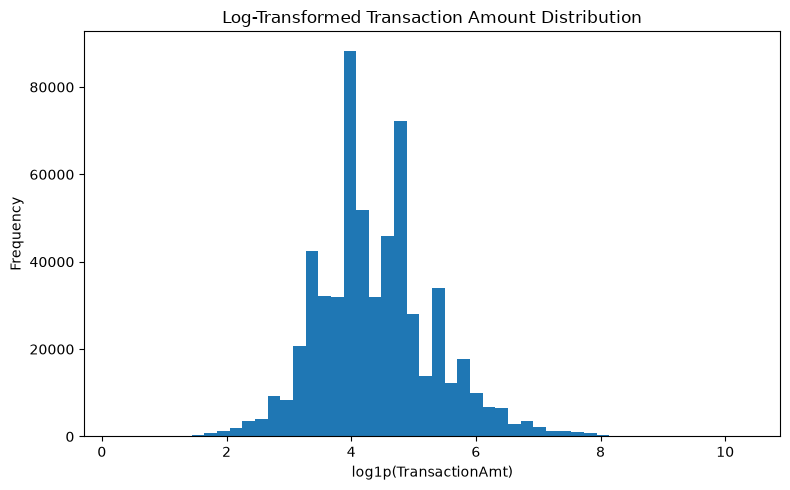

In [5]:
plt.figure(figsize=(8, 5))
feature_df["TransactionAmt_log"].plot(kind="hist", bins=50)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log1p(TransactionAmt)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "transaction_amount_log_distribution.png")
plt.show()  
plt.close()

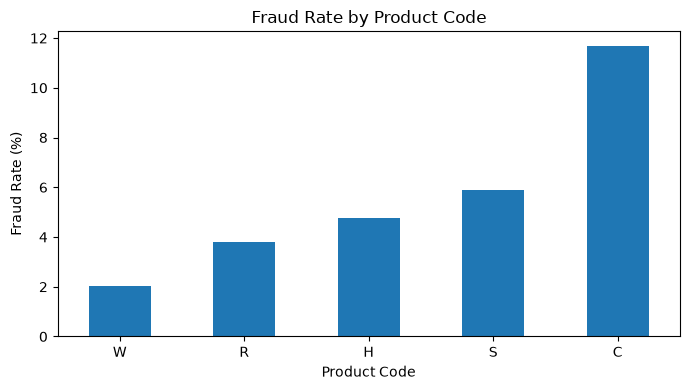

In [6]:
fraud_rate_by_product = feature_df.groupby("ProductCD")["isFraud"].mean().sort_values() * 100
plt.figure(figsize=(7, 4))
fraud_rate_by_product.plot(kind="bar")
plt.title("Fraud Rate by Product Code")
plt.xlabel("Product Code")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_rate_by_product_code.png")
plt.show()
plt.close()

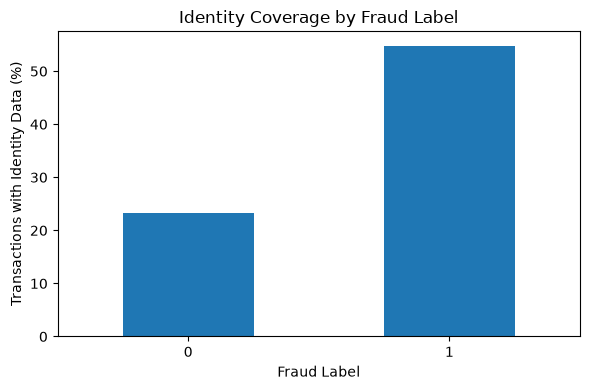

In [7]:
coverage_by_fraud = feature_df.groupby("isFraud")["has_identity"].mean() * 100
plt.figure(figsize=(6, 4))
coverage_by_fraud.plot(kind="bar")
plt.title("Identity Coverage by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Transactions with Identity Data (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "identity_coverage_by_fraud.png")
plt.show()
plt.close()

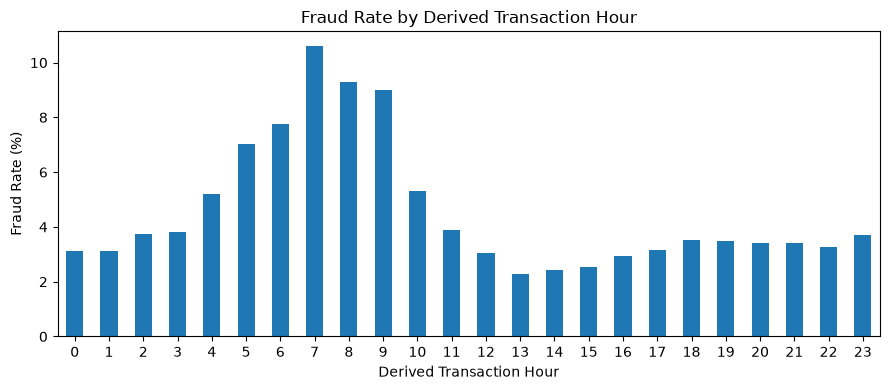

In [8]:
hourly_fraud_rate = feature_df.groupby("transaction_hour")["isFraud"].mean() * 100
plt.figure(figsize=(9, 4))
hourly_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Derived Transaction Hour")
plt.xlabel("Derived Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_rate_by_transaction_hour.png")
plt.show()  
plt.close()

In [9]:
summary_df.to_csv(FEATURE_STRATEGY_SUMMARY_FILE, index=False)
print(summary_df)
print("\nFraud rate by ProductCD (%):")
print((feature_df.groupby("ProductCD")["isFraud"].mean() * 100).sort_values(ascending=False))
print("\nIdentity coverage by fraud label (%):")
print((feature_df.groupby("isFraud")["has_identity"].mean() * 100))

             feature_name data_type  missing_percentage  unique_values  \
0          TransactionAmt   float64                 0.0          20902   
1      TransactionAmt_log   float64                 0.0          20902   
2        transaction_hour     int64                 0.0             24   
3         transaction_day     int64                 0.0            182   
4               ProductCD       str                 0.0              5   
5            has_identity     int64                 0.0              2   
6   P_emaildomain_missing     int64                 0.0              2   
7   R_emaildomain_missing     int64                 0.0              2   
8      email_domain_match     int64                 0.0              3   
9      card_missing_count     int64                 0.0              5   
10  address_missing_count     int64                 0.0              2   

                                       example_values  
0                      [68.5, 29.0, 59.0, 50.0, 50.0]  